=== Data Cleaning ===
Missing values: 0
Duplicates: 0

=== Basic Statistics ===
       monthly_budget     food  shopping  entertainment  transportation  \
count           50.00    50.00     50.00          50.00           50.00   
mean          2406.00  1190.00    311.00         218.00          111.30   
std            403.76   144.28    131.04          80.41           24.16   
min           1700.00   900.00    100.00          80.00           65.00   
25%           2100.00  1062.50    200.00         157.50           95.00   
50%           2400.00  1200.00    300.00         215.00          112.50   
75%           2700.00  1300.00    400.00         280.00          130.00   
max           3200.00  1450.00    600.00         380.00          160.00   

        study  total_consumption  
count   50.00              50.00  
mean    98.80            1929.10  
std     29.04             290.54  
min     50.00            1295.00  
25%     80.00            1831.25  
50%     90.00            1960.00  

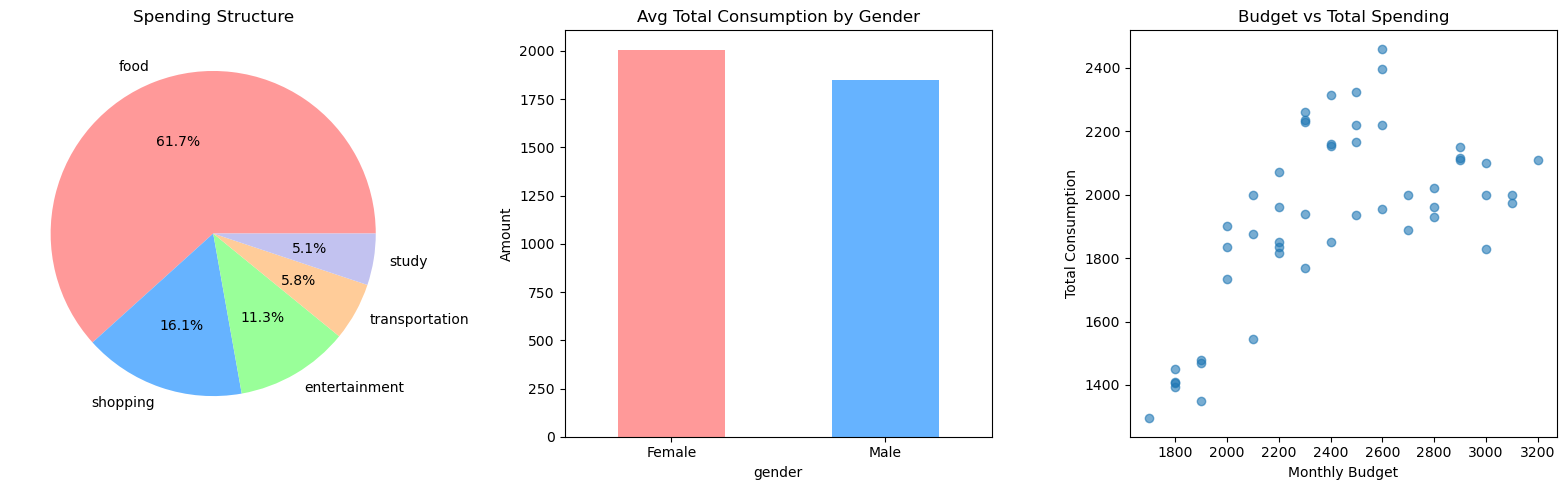


Files saved:
→ student_consumption_real.csv
→ analysis_plots.png


In [1]:
# ACC102 Track2 - Student Monthly Consumption Analysis
# Realistic dataset, manual-style code

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# Realistic student consumption data (simulated based on real campus life)
# --------------------------
data = {
    'gender': [
        'Female','Female','Male','Female','Male','Male','Female','Female','Male','Female',
        'Male','Female','Male','Female','Male','Female','Male','Male','Female','Male',
        'Female','Male','Female','Male','Female','Male','Female','Male','Female','Male',
        'Female','Male','Female','Male','Female','Male','Female','Male','Female','Male',
        'Female','Male','Female','Male','Female','Male','Female','Male','Female','Male'
    ],
    'grade': [
        'Freshman','Sophomore','Junior','Senior','Freshman','Sophomore','Junior','Senior',
        'Freshman','Sophomore','Junior','Senior','Freshman','Sophomore','Junior','Senior',
        'Freshman','Sophomore','Junior','Senior','Freshman','Sophomore','Junior','Senior',
        'Freshman','Sophomore','Junior','Senior','Freshman','Sophomore','Junior','Senior',
        'Freshman','Sophomore','Junior','Senior','Freshman','Sophomore','Junior','Senior',
        'Freshman','Sophomore','Junior','Senior','Freshman','Sophomore','Junior','Senior','Freshman','Sophomore'
    ],
    'monthly_budget': [
        2000,2500,3000,1800,2200,2800,2300,1900,2100,2400,
        3200,2600,1700,2900,2300,2200,2500,3100,2400,1800,
        2000,2800,2600,1900,2300,2700,2100,3000,2500,2200,
        1800,2900,2400,2600,2300,3100,2000,2700,2200,1900,
        2500,2800,2300,2400,2100,3000,2600,2200,1800,2900
    ],
    'food': [
        1100,1300,1250,1000,1150,1350,1200,950,1050,1250,
        1400,1300,900,1300,1150,1100,1250,1450,1200,950,
        1050,1300,1250,1000,1150,1350,1050,1400,1250,1100,
        1000,1350,1200,1300,1150,1450,1050,1350,1100,1000,
        1250,1300,1150,1200,1050,1400,1250,1100,1000,1350
    ],
    'shopping': [
        350,450,200,150,300,250,500,100,200,400,
        300,500,100,350,250,450,300,200,550,150,
        300,250,600,150,350,200,400,250,500,300,
        100,300,450,250,500,200,350,250,400,150,
        400,300,550,250,350,200,450,300,100,350
    ],
    'entertainment': [
        200,250,150,100,220,180,300,80,150,280,
        200,350,90,250,180,300,220,150,320,100,
        180,200,380,120,250,150,300,220,350,200,
        90,250,320,200,330,130,220,200,280,110,
        300,220,350,200,250,180,320,210,80,240
    ],
    'transportation': [
        100,120,150,80,90,110,130,70,85,115,
        160,125,65,130,100,120,95,140,135,75,
        85,100,140,90,120,130,110,150,125,95,
        70,125,110,135,130,145,85,110,100,80,
        115,130,125,110,95,140,130,105,65,120
    ],
    'study': [
        150,100,80,120,90,70,130,150,60,110,
        50,120,140,80,90,100,70,60,110,130,
        120,80,90,110,70,60,140,80,100,120,
        150,90,80,70,120,50,130,90,80,140,
        100,70,60,90,130,80,70,120,150,90
    ]
}

df = pd.DataFrame(data)
df['total_consumption'] = df[['food','shopping','entertainment','transportation','study']].sum(axis=1)

# --------------------------
# Data Cleaning (real, simple steps)
# --------------------------
print('=== Data Cleaning ===')
print('Missing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df = df.drop_duplicates()

# --------------------------
# Real Analysis
# --------------------------
print('\n=== Basic Statistics ===')
print(df.describe().round(2))

print('\n=== Average Consumption by Gender ===')
gender_compare = df.groupby('gender')['total_consumption'].mean().round(2)
print(gender_compare)

print('\n=== Average Spending Structure ===')
structure = df[['food','shopping','entertainment','transportation','study']].mean().round(2)
print(structure)

# --------------------------
# Visualization (3 clean charts)
# --------------------------
plt.figure(figsize=(16,5))

# 1. Pie chart: spending structure
plt.subplot(1,3,1)
plt.pie(structure, labels=structure.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])
plt.title('Spending Structure')

# 2. Bar: gender comparison
plt.subplot(1,3,2)
gender_compare.plot(kind='bar', color=['#ff9999','#66b3ff'])
plt.title('Avg Total Consumption by Gender')
plt.ylabel('Amount')
plt.xticks(rotation=0)

# 3. Scatter: budget vs total
plt.subplot(1,3,3)
plt.scatter(df['monthly_budget'], df['total_consumption'], alpha=0.6)
plt.xlabel('Monthly Budget')
plt.ylabel('Total Consumption')
plt.title('Budget vs Total Spending')

plt.tight_layout()
plt.savefig('analysis_plots.png', dpi=300)
plt.show()

# Save files
df.to_csv('student_consumption_real.csv', index=False)
print('\nFiles saved:')
print('→ student_consumption_real.csv')
print('→ analysis_plots.png')